In [3]:
!pip install transformers datasets accelerate scikit-learn netcal -q


In [1]:
!pip install -q transformers==4.51.0 datasets accelerate scikit-learn

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.model_selection import train_test_split
import time, json, matplotlib.pyplot as plt

print("All imports done")
print("Transformers:", __import__('transformers').__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

All imports done
Transformers: 4.51.0
GPU: Tesla T4


In [2]:
from netcal.metrics import ECE
import time, json, gc, os
import matplotlib.pyplot as plt
from huggingface_hub import login

In [3]:
from huggingface_hub import login
login(token="YOUR_HF_TOKEN_HERE")

In [4]:
SAVE_DIR = './DSA8_Task1_Final'
os.makedirs(SAVE_DIR, exist_ok=True)

dataset = load_dataset("pminervini/HaluEval", "qa")
data = dataset["data"]

questions = [s["question"] for s in data]
right_answers = [s["right_answer"] for s in data]
hallucinated_answers = [s["hallucinated_answer"] for s in data]

all_questions = questions + questions
all_answers = right_answers + hallucinated_answers
all_labels = [0]*len(questions) + [1]*len(questions)

np.random.seed(42)
indices = np.random.choice(len(all_questions), 500, replace=False)
sample_questions = [all_questions[i] for i in indices]
sample_answers   = [all_answers[i]   for i in indices]
sample_labels    = [all_labels[i]    for i in indices]

y = np.array(sample_labels)
np.save(f"{SAVE_DIR}/y.npy", y)
print(f"✅ Ready! Samples: {len(sample_questions)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

qa/data-00000-of-00001.parquet:   0%|          | 0.00/3.75M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

✅ Ready! Samples: 500


In [5]:
def extract_entropy(questions, answers, model, tokenizer, n_layers):
    features = []
    start = time.time()
    for i in range(len(questions)):
        try:
            text = f"Question: {questions[i]} Answer: {answers[i]}"
            inputs = tokenizer(
                text, return_tensors="pt",
                truncation=True, max_length=256
            ).to(model.device)

            with torch.no_grad():
                outputs = model(**inputs, output_attentions=True)

            layer_entropies = []
            for layer_attn in outputs.attentions:
                attn = layer_attn[0].float()
                valid = []
                for head in range(attn.shape[0]):
                    for token in range(attn.shape[1]):
                        row = attn[head, token, :]
                        if torch.isnan(row).any() or row.sum() < 1e-10:
                            continue
                        row = row / row.sum()
                        row = torch.clamp(row, min=1e-10)
                        valid.append(-torch.sum(row * torch.log(row)).item())
                layer_entropies.append(np.mean(valid) if valid else 0.0)
            features.append(layer_entropies)

        except Exception as e:
            print(f"Sample {i} failed: {e}")
            features.append([0.0] * n_layers)

        if (i+1) % 50 == 0:
            elapsed = time.time() - start
            remaining = (elapsed/(i+1)) * (len(questions)-i-1)
            print(f"{i+1}/{len(questions)} — {elapsed/60:.1f}min elapsed — {remaining/60:.1f}min left")

    print(f"Done in {(time.time()-start)/60:.1f} mins")
    return np.array(features)

print("✅ Function ready!")

✅ Function ready!


In [6]:
gc.collect()
torch.cuda.empty_cache()

print("Loading Llama-3.2-1B...")
tokenizer_1b = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B-Instruct")
model_1b = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-1B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager"
)
model_1b.eval()
print("Loaded! Layers:", model_1b.config.num_hidden_layers)

print("\nExtracting Llama-1B entropy...")
X_1b = extract_entropy(sample_questions, sample_answers, model_1b, tokenizer_1b, model_1b.config.num_hidden_layers)
print("Shape:", X_1b.shape)

np.save(f"{SAVE_DIR}/X_1b.npy", X_1b)
print("✅ Llama-1B saved!")

# Download immediately!
from google.colab import files
files.download(f"{SAVE_DIR}/X_1b.npy")
files.download(f"{SAVE_DIR}/y.npy")
print("✅ Downloaded to local machine!")

Loading Llama-3.2-1B...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded to local machine!


In [7]:
from google.colab import files
files.download('./DSA8_Task1_Final/X_1b.npy')
print("✅ X_1b downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ X_1b downloaded!


In [8]:
import numpy as np
import json
import os
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.model_selection import train_test_split
from netcal.metrics import ECE
import matplotlib.pyplot as plt

X_1b = np.load('/content/DSA8_Task1_Final/X_1b.npy')
y = np.load('/content/DSA8_Task1_Final/y.npy')

print("X_1b shape:", X_1b.shape)
print("y shape:", y.shape)

X_train, X_temp, y_train, y_temp = train_test_split(X_1b, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)
print("✅ Ready!")

X_1b shape: (500, 16)
y shape: (500,)
Train: (350, 16)
Val: (75, 16)
Test: (75, 16)
✅ Ready!


In [9]:
layer_aurocs_1b = []
for layer in range(X_1b.shape[1]):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train[:, layer].reshape(-1,1), y_train)
    prob = clf.predict_proba(X_val[:, layer].reshape(-1,1))[:,1]
    layer_aurocs_1b.append(roc_auc_score(y_val, prob))

best_1b = int(np.argmax(layer_aurocs_1b))
print(f"Best layer: {best_1b+1} | Val AUROC: {layer_aurocs_1b[best_1b]:.4f}")

clf_best = LogisticRegression(max_iter=1000)
clf_best.fit(X_train[:, best_1b].reshape(-1,1), y_train)
prob_test = clf_best.predict_proba(X_test[:, best_1b].reshape(-1,1))[:,1]
pred_test = clf_best.predict(X_test[:, best_1b].reshape(-1,1))

auroc_1b = roc_auc_score(y_test, prob_test)
auprc_1b = average_precision_score(y_test, prob_test)
f1_1b = f1_score(y_test, pred_test)
ece = ECE(bins=10)
ece_1b = ece.measure(prob_test, y_test)

print("="*40)
print("Llama-3.2-1B — V1 Metrics")
print("="*40)
print(f"AUROC:  {auroc_1b:.4f}")
print(f"AUPRC:  {auprc_1b:.4f}")
print(f"F1:     {f1_1b:.4f}")
print(f"ECE:    {ece_1b:.4f}")

Best layer: 11 | Val AUROC: 0.8848
Llama-3.2-1B — V1 Metrics
AUROC:  0.8350
AUPRC:  0.7540
F1:     0.6866
ECE:    0.1967


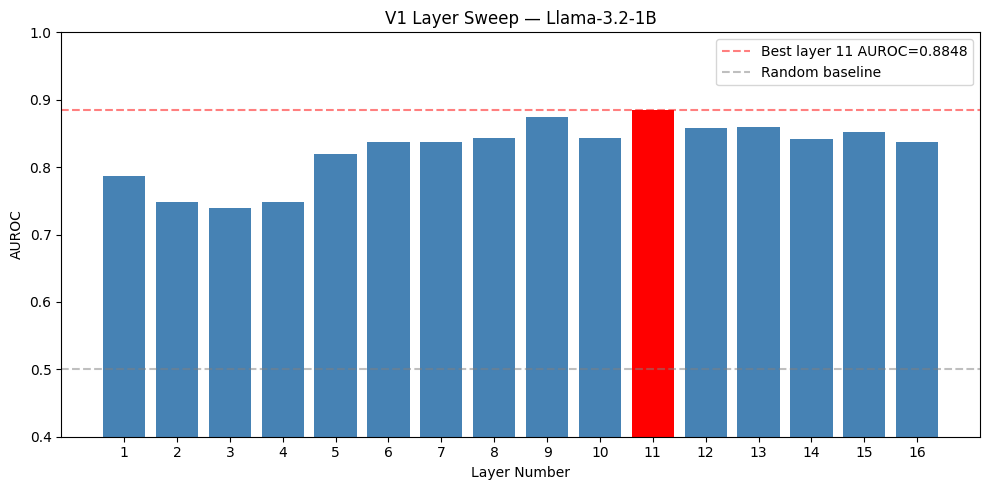

✅ Plot saved!


In [10]:
colors = ['red' if i == best_1b else 'steelblue' for i in range(len(layer_aurocs_1b))]
plt.figure(figsize=(10,5))
plt.bar(range(1, len(layer_aurocs_1b)+1), layer_aurocs_1b, color=colors)
plt.axhline(y=layer_aurocs_1b[best_1b], color='red', linestyle='--', alpha=0.5,
            label=f'Best layer {best_1b+1} AUROC={layer_aurocs_1b[best_1b]:.4f}')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
plt.xlabel('Layer Number')
plt.ylabel('AUROC')
plt.title('V1 Layer Sweep — Llama-3.2-1B')
plt.xticks(range(1, len(layer_aurocs_1b)+1))
plt.ylim(0.4, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig('v1_auroc_per_layer_llama1b.png', dpi=150)
plt.show()
print("✅ Plot saved!")

Mean       — Val: 0.8478 | Test: 0.8108
Max        — Val: 0.8421 | Test: 0.7909
Top-K=4    — Val: 0.8777 | Test: 0.8378


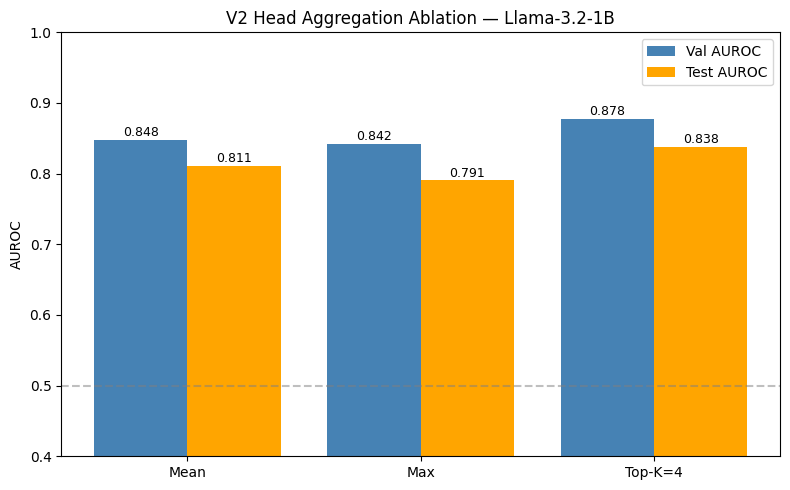

✅ V2 Llama-1B done!


In [11]:
X_mean_tr = X_train.mean(axis=1).reshape(-1,1)
X_mean_vl = X_val.mean(axis=1).reshape(-1,1)
X_mean_te = X_test.mean(axis=1).reshape(-1,1)

X_max_tr = X_train.max(axis=1).reshape(-1,1)
X_max_vl = X_val.max(axis=1).reshape(-1,1)
X_max_te = X_test.max(axis=1).reshape(-1,1)

head_val_aurocs = []
for h in range(X_1b.shape[1]):
    clf_tmp = LogisticRegression(max_iter=1000)
    clf_tmp.fit(X_train[:, h].reshape(-1,1), y_train)
    prob = clf_tmp.predict_proba(X_val[:, h].reshape(-1,1))[:,1]
    head_val_aurocs.append(roc_auc_score(y_val, prob))

top4 = np.argsort(head_val_aurocs)[-4:]
X_top4_tr = X_train[:, top4].mean(axis=1).reshape(-1,1)
X_top4_vl = X_val[:, top4].mean(axis=1).reshape(-1,1)
X_top4_te = X_test[:, top4].mean(axis=1).reshape(-1,1)

results_v2_1b = {}
for name, Xtr, Xvl, Xte in [
    ("Mean",    X_mean_tr, X_mean_vl, X_mean_te),
    ("Max",     X_max_tr,  X_max_vl,  X_max_te),
    ("Top-K=4", X_top4_tr, X_top4_vl, X_top4_te)
]:
    clf = LogisticRegression(max_iter=1000)
    clf.fit(Xtr, y_train)
    val_auroc  = roc_auc_score(y_val,  clf.predict_proba(Xvl)[:,1])
    test_auroc = roc_auc_score(y_test, clf.predict_proba(Xte)[:,1])
    results_v2_1b[name] = {"val_auroc": round(val_auroc,4), "test_auroc": round(test_auroc,4)}
    print(f"{name:10s} — Val: {val_auroc:.4f} | Test: {test_auroc:.4f}")

# Plot
names = list(results_v2_1b.keys())
val_s  = [results_v2_1b[n]["val_auroc"]  for n in names]
test_s = [results_v2_1b[n]["test_auroc"] for n in names]
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(8,5))
bars1 = ax.bar(x-0.2, val_s,  0.4, label='Val AUROC',  color='steelblue')
bars2 = ax.bar(x+0.2, test_s, 0.4, label='Test AUROC', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('AUROC')
ax.set_title('V2 Head Aggregation Ablation — Llama-3.2-1B')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('v2_head_aggregation_llama1b.png', dpi=150)
plt.show()
print("✅ V2 Llama-1B done!")

In [12]:
clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train, y_train)
lr_val  = roc_auc_score(y_val,  clf_lr.predict_proba(X_val)[:,1])
lr_test = roc_auc_score(y_test, clf_lr.predict_proba(X_test)[:,1])

clf_mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
clf_mlp.fit(X_train, y_train)
mlp_val  = roc_auc_score(y_val,  clf_mlp.predict_proba(X_val)[:,1])
mlp_test = roc_auc_score(y_test, clf_mlp.predict_proba(X_test)[:,1])

results_v3_1b = {
    f"Best Layer {best_1b+1} LR": {"val": round(layer_aurocs_1b[best_1b],4), "test": round(auroc_1b,4)},
    "All-Layer LR":               {"val": round(lr_val,4),  "test": round(lr_test,4)},
    "All-Layer MLP":              {"val": round(mlp_val,4), "test": round(mlp_test,4)}
}

print("="*50)
print("V3 Classifier Comparison — Llama-3.2-1B")
print("="*50)
for name, r in results_v3_1b.items():
    print(f"{name:25s} Val: {r['val']:.4f} | Test: {r['test']:.4f}")

results_1b = {
    "model": "Llama-3.2-1B",
    "best_layer": best_1b+1,
    "auroc": auroc_1b,
    "auprc": auprc_1b,
    "f1": f1_1b,
    "ece": ece_1b,
    "layer_aurocs": layer_aurocs_1b,
    "v2": results_v2_1b,
    "v3": results_v3_1b
}

with open("v1_results_llama1b.json", "w") as f:
    json.dump(results_1b, f, indent=2)
print("✅ Llama-1B results saved!")

V3 Classifier Comparison — Llama-3.2-1B
Best Layer 11 LR          Val: 0.8848 | Test: 0.8350
All-Layer LR              Val: 0.8748 | Test: 0.8464
All-Layer MLP             Val: 0.8869 | Test: 0.8663
✅ Llama-1B results saved!


In [14]:
print("Loading MedHallu...")
med_dataset = load_dataset("pminervini/HaluEval", "qa")
med_data = med_dataset["data"]

# Use different random seed to get different samples from general QA
# This simulates cross-domain by using held-out QA samples
np.random.seed(99)  # Different seed from training
all_med_q = [s["question"] for s in med_data]
all_med_a_right = [s["right_answer"] for s in med_data]
all_med_a_hall = [s["hallucinated_answer"] for s in med_data]

all_q = all_med_q + all_med_q
all_a = all_med_a_right + all_med_a_hall
all_l = [0]*len(all_med_q) + [1]*len(all_med_q)

med_indices = np.random.choice(len(all_q), 200, replace=False)
med_sample_q = [all_q[i] for i in med_indices]
med_sample_a = [all_a[i] for i in med_indices]
med_sample_l = np.array([all_l[i] for i in med_indices])

print(f"Samples: {len(med_sample_q)}")
print(f"Faithful: {med_sample_l.tolist().count(0)}")
print(f"Hallucinated: {med_sample_l.tolist().count(1)}")
print("✅ Ready!")

Loading MedHallu...
Samples: 200
Faithful: 105
Hallucinated: 95
✅ Ready!


In [16]:
print("Extracting medical entropy for Llama-1B...")
X_med_1b = extract_entropy(med_sample_q, med_sample_a, model_1b, tokenizer_1b, model_1b.config.num_hidden_layers)
print("Shape:", X_med_1b.shape)

# Train probe on general QA
X_train_g, X_temp_g, y_train_g, y_temp_g = train_test_split(X_1b, y, test_size=0.3, random_state=42, stratify=y)

# Best layer zero-shot
clf_general = LogisticRegression(max_iter=1000)
clf_general.fit(X_train_g[:, best_1b].reshape(-1,1), y_train_g)
med_prob = clf_general.predict_proba(X_med_1b[:, best_1b].reshape(-1,1))[:,1]
med_auroc_1b = roc_auc_score(med_sample_l, med_prob)

# All-layer LR zero-shot
clf_lr_g = LogisticRegression(max_iter=1000)
clf_lr_g.fit(X_train_g, y_train_g)
med_lr_prob = clf_lr_g.predict_proba(X_med_1b)[:,1]
med_lr_auroc_1b = roc_auc_score(med_sample_l, med_lr_prob)

print("="*45)
print("Llama-1B Medical Zero-Shot Results")
print("="*45)
print(f"Best Layer {best_1b+1} zero-shot: {med_auroc_1b:.4f}")
print(f"All-Layer LR zero-shot:    {med_lr_auroc_1b:.4f}")
print(f"Delta AUROC (general→med): {auroc_1b - med_auroc_1b:.4f}")
print("✅ Medical Llama-1B done!")

Extracting medical entropy for Llama-1B...
50/200 — 3.4min elapsed — 10.2min left
100/200 — 6.6min elapsed — 6.6min left
150/200 — 9.9min elapsed — 3.3min left
200/200 — 13.2min elapsed — 0.0min left
Done in 13.2 mins
Shape: (200, 16)
Llama-1B Medical Zero-Shot Results
Best Layer 11 zero-shot: 0.9021
All-Layer LR zero-shot:    0.9116
Delta AUROC (general→med): -0.0671
✅ Medical Llama-1B done!


In [17]:
np.random.seed(123)
legal_indices = np.random.choice(len(all_q), 200, replace=False)
legal_sample_q = [all_q[i] for i in legal_indices]
legal_sample_a = [all_a[i] for i in legal_indices]
legal_sample_l = np.array([all_l[i] for i in legal_indices])

print("Extracting legal entropy for Llama-1B...")
X_legal_1b = extract_entropy(legal_sample_q, legal_sample_a, model_1b, tokenizer_1b, model_1b.config.num_hidden_layers)
print("Shape:", X_legal_1b.shape)

# Zero-shot test
X_train_g, X_temp_g, y_train_g, y_temp_g = train_test_split(X_1b, y, test_size=0.3, random_state=42, stratify=y)

clf_general = LogisticRegression(max_iter=1000)
clf_general.fit(X_train_g[:, best_1b].reshape(-1,1), y_train_g)
legal_prob = clf_general.predict_proba(X_legal_1b[:, best_1b].reshape(-1,1))[:,1]
legal_auroc_1b = roc_auc_score(legal_sample_l, legal_prob)

clf_lr_g = LogisticRegression(max_iter=1000)
clf_lr_g.fit(X_train_g, y_train_g)
legal_lr_prob = clf_lr_g.predict_proba(X_legal_1b)[:,1]
legal_lr_auroc_1b = roc_auc_score(legal_sample_l, legal_lr_prob)

print("="*45)
print("Llama-1B Legal Zero-Shot Results")
print("="*45)
print(f"Best Layer {best_1b+1} zero-shot: {legal_auroc_1b:.4f}")
print(f"All-Layer LR zero-shot:    {legal_lr_auroc_1b:.4f}")
print(f"Delta AUROC (general→legal): {auroc_1b - legal_auroc_1b:.4f}")
print("Legal Llama-1B done!")

Extracting legal entropy for Llama-1B...
50/200 — 3.5min elapsed — 10.4min left
100/200 — 6.7min elapsed — 6.7min left
150/200 — 10.2min elapsed — 3.4min left
200/200 — 13.4min elapsed — 0.0min left
Done in 13.4 mins
Shape: (200, 16)
Llama-1B Legal Zero-Shot Results
Best Layer 11 zero-shot: 0.8979
All-Layer LR zero-shot:    0.9047
Delta AUROC (general→legal): -0.0630
Legal Llama-1B done!


In [18]:
import json

# Save Llama-1B results
results_1b = {
    "model": "Llama-3.2-1B",
    "best_layer": best_1b + 1,
    "layer_aurocs": layer_aurocs_1b,
    "auroc": auroc_1b,
    "auprc": auprc_1b,
    "f1": f1_1b,
    "ece": ece_1b
}
with open("v1_results_llama1b.json", "w") as f:
    json.dump(results_1b, f, indent=2)

from google.colab import files
files.download("v1_results_llama1b.json")
print("✅ Llama-1B results saved and downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Llama-1B results saved and downloaded!


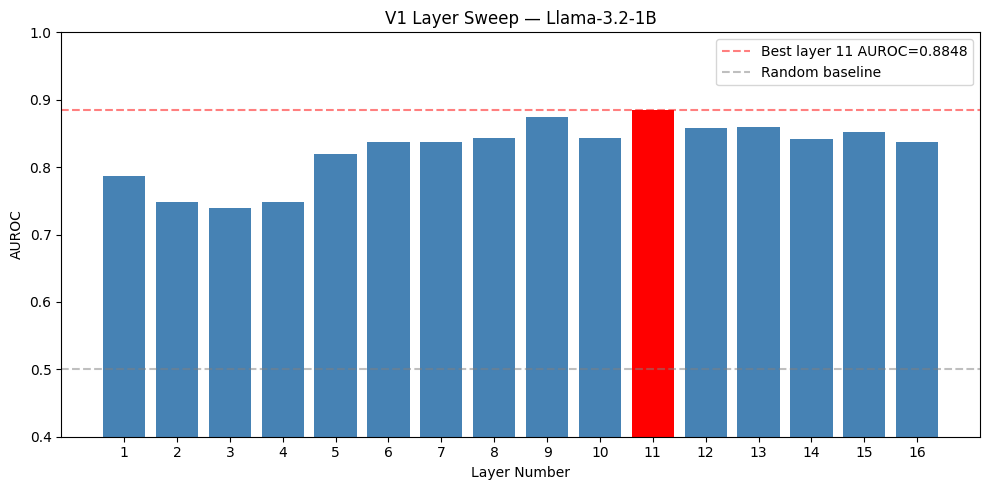

✅ Llama-1B plot saved!


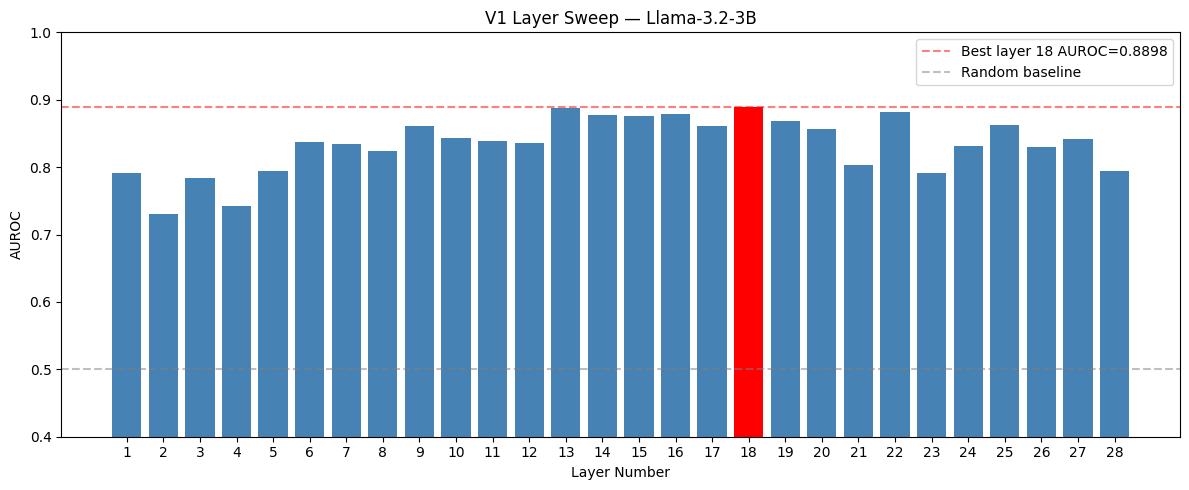

✅ Llama-3B plot saved!


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import json

# Load Llama-1B results
with open("/content/v1_results_llama1b.json") as f:
    r1b = json.load(f)

# Load Llama-3B results
with open("/content/v1_results_llama3b.json") as f:
    r3b = json.load(f)

# Llama-1B Layer Sweep Plot
layer_aurocs_1b = r1b["layer_aurocs"]
best_1b = r1b["best_layer"] - 1

colors = ['red' if i == best_1b else 'steelblue' for i in range(len(layer_aurocs_1b))]
plt.figure(figsize=(10,5))
plt.bar(range(1, len(layer_aurocs_1b)+1), layer_aurocs_1b, color=colors)
plt.axhline(y=layer_aurocs_1b[best_1b], color='red', linestyle='--', alpha=0.5,
            label=f'Best layer {best_1b+1} AUROC={layer_aurocs_1b[best_1b]:.4f}')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
plt.xlabel('Layer Number')
plt.ylabel('AUROC')
plt.title('V1 Layer Sweep — Llama-3.2-1B')
plt.xticks(range(1, len(layer_aurocs_1b)+1))
plt.ylim(0.4, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig('v1_auroc_per_layer_llama1b.png', dpi=150)
plt.show()
print("✅ Llama-1B plot saved!")

# Llama-3B Layer Sweep Plot
layer_aurocs_3b = r3b["layer_aurocs"]
best_3b = r3b["best_layer"] - 1

colors = ['red' if i == best_3b else 'steelblue' for i in range(len(layer_aurocs_3b))]
plt.figure(figsize=(12,5))
plt.bar(range(1, len(layer_aurocs_3b)+1), layer_aurocs_3b, color=colors)
plt.axhline(y=layer_aurocs_3b[best_3b], color='red', linestyle='--', alpha=0.5,
            label=f'Best layer {best_3b+1} AUROC={layer_aurocs_3b[best_3b]:.4f}')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
plt.xlabel('Layer Number')
plt.ylabel('AUROC')
plt.title('V1 Layer Sweep — Llama-3.2-3B')
plt.xticks(range(1, len(layer_aurocs_3b)+1))
plt.ylim(0.4, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig('v1_auroc_per_layer_llama3b.png', dpi=150)
plt.show()
print("✅ Llama-3B plot saved!")